In [9]:
# Test what resistance unit is being returned - with forced reload
import importlib
import SMU_functions
importlib.reload(SMU_functions)
from SMU_functions import auto_scale_resistance

test_resistance_data = np.array([1e6, 2e6, 5e6])  # 1-5 MΩ range
scaled_data, unit_string, scale_factor = auto_scale_resistance(test_resistance_data)
print(f"Test resistance data: {test_resistance_data}")
print(f"Scaled data: {scaled_data}")
print(f"Unit string: '{unit_string}' (repr: {repr(unit_string)})")
print(f"Scale factor: {scale_factor}")
print(f"Has unicode omega: {'Ω' in unit_string}")
print(f"Contains MΩ: {'MΩ' in unit_string}")
print(f"Is LaTeX format: {unit_string.startswith('M$')}")

Test resistance data: [1000000. 2000000. 5000000.]
Scaled data: [1. 2. 5.]
Unit string: 'M$\Omega$' (repr: 'M$\\Omega$')
Scale factor: 1e-06
Has unicode omega: False
Contains MΩ: False
Is LaTeX format: True


In [1]:
#source TFAvenv/bin/activate (launching and exiting the virtual environment containing the required modules, stored in the working directory)
#TFAvenv/bin/python your_script.py - for running a script in the virtual environment
#source deactivate

#import all the libraries needed
from import_dep import *
import importlib

# import my functions stored in the file 'functions' which can then be called with functions.function_name()
from SMU import SMU
import SMU_functions
importlib.reload(SMU_functions)  # Force reload to get updated function signatures with auto-scaling
from SMU_functions import plot_IV, plot_CV, plot_resistance

# import custom plot style and colorbar functions
import plot_style
importlib.reload(plot_style)  # Force reload to get updated markersize parameter
from plot_style import set_plot_style

# Define the path to the root directory containing all the XRD data
root_SMU = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/DR012'
output_SMU = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/DR012/Output'

### Plotting and Output Variables 
export_data = True # set to True to export the data to a powerpoint presentation and as svg files and export to path_out
fig_format = 'png' # format of the figure to be saved

powerpoint_string = 'DR012_switching' # string to be added to the powerpoint file name

plot_transparency = True # set to True to make the data plots transparent

# Custom plot style settings with small markersize
# This will now work because plot_style.py respects the markersize parameter
fig_size = set_plot_style(export_data=export_data, use_tex=True, markersize=0.1)

# Alternative: You can also pass markersize directly to each plot function
# plot_IV(..., markersize=0.1)
# plot_CV(..., markersize=0.1) 
# plot_resistance(..., markersize=0.1)

print("Updated SMU functions with auto-scaling current units!")

Updated SMU functions with auto-scaling current units!


In [10]:
# Test the SMU class by loading data
print("Testing SMU class...")

# Create SMU object
smu_DR012 = SMU(root_SMU)

# # Display basic information
# print(f"\nSMU object: {smu_DR012}")
# print(f"CV run numbers: {smu_DR012.cv_run_nums[:10]}...")  # Show first 10
# print(f"IV run numbers: {smu_DR012.iv_run_nums[:10]}...")  # Show first 10

# # Show sample CV data
# if smu_DR012.cv_data:
#     print(f"\nSample CV data (first file):")
#     print(smu_DR012.cv_data[0].head())

# # Show sample IV data  
# if smu_DR012.iv_data:
#     print(f"\nSample IV data (first file):")
#     print(smu_DR012.iv_data[0].head())

Testing SMU class...
Found 425 Excel files
Loaded 16 CV files and 409 IV files
Loaded 16 CV files and 409 IV files


# IV Plotting

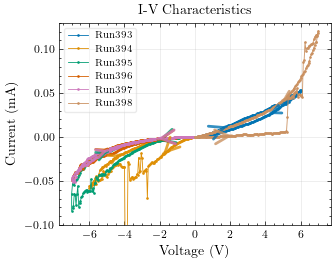

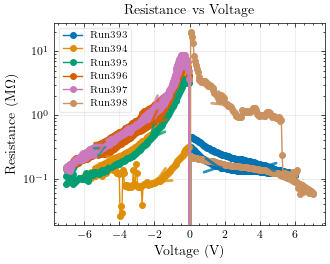

In [11]:
## IV Analysis with Direction Arrows

# Select specific runs for analysis using the built-in methods

#selected_iv_runs = [ 398, 399, 401, 402] 
#selected_iv_runs = [389, 390,392, 404, 398]
selected_iv_runs = [393, 394, 395, 396, 397, 398]

fig_iv = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       log_plot=False, plot_arrows=True,
                        y_lim=[-0.10, 0.13],
                        line_width =0.6,
                        markersize=0.9,
                       export_data=export_data, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)

fig_R = plot_resistance([smu_DR012], run_nums=selected_iv_runs, 
                       log_plot=True,
                       export_data=export_data, plot_arrows = True, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)

# CV Plotting

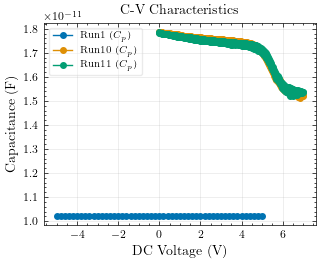


=== Testing Resistance Plot with Arrows ===


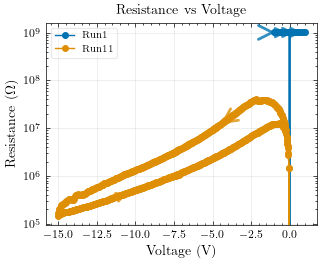

In [ ]:
## CV Analysis
selected_cv_runs = [1, 10, 11] 

# Use get_cv_data and get_iv_data methods for clean data extraction
cv_data, cv_labels = smu_DR012.get_cv_data(run_nums=selected_cv_runs)

# Plot using the extracted data
fig_cv = plot_CV([smu_DR012], run_nums=selected_cv_runs, log_plot=False,
                 export_data=export_data, output_SMU=output_SMU,
                 plot_transparency=plot_transparency)

## Resistance Analysis with Arrows
print("\n=== Testing Resistance Plot with Arrows ===")
selected_resistance_runs = [1, 11]  # Fewer runs for clearer visualization

# Test resistance plot with arrows
fig_r = plot_resistance([smu_DR012], run_nums=selected_resistance_runs, 
                       log_plot=True, plot_arrows=True,
                       export_data=export_data, output_SMU=output_SMU,
                       plot_transparency=plot_transparency)

=== Testing x_lim masking with auto y-scaling ===
1. IV plot with x_lim=[0, 5] - y-axis should auto-scale to data in this range


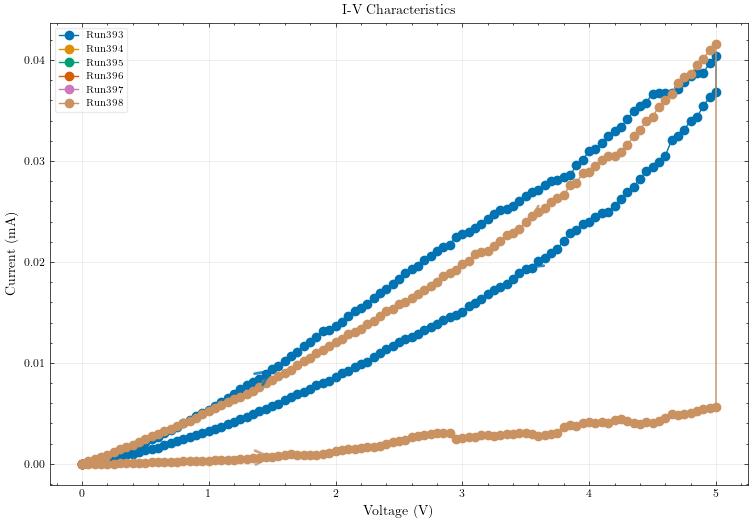

2. Resistance plot with x_lim=[-2, 2] - y-axis should auto-scale to resistance in this range


RuntimeError: latex was not able to process the following string:
b'Resistance (M\\u03a9)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpwqoq57re d56699d583ff7acd5571b51222ab172b.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./d56699d583ff7acd5571b51222ab172b.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-02-20>
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2024/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2024/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2024/texm

<Figure size 900x600 with 1 Axes>

Now y-axis automatically scales to show only the data within the x_lim range!


In [6]:
## Testing x_lim Data Masking with Auto Y-scaling

print("=== Testing x_lim masking with auto y-scaling ===")

# Test 1: IV plot with x_lim masking (y should auto-scale to visible data)
print("1. IV plot with x_lim=[0, 5] - y-axis should auto-scale to data in this range")
fig_iv_masked = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       x_lim=[0, 5],  # Only show 0 to 5V range - y will auto-scale
                       log_plot=False, plot_arrows=True,
                       export_data=False, output_SMU=output_SMU)

# Test 2: Resistance plot with x_lim masking
print("2. Resistance plot with x_lim=[-2, 2] - y-axis should auto-scale to resistance in this range")
fig_R_masked = plot_resistance([smu_DR012], run_nums=selected_iv_runs, 
                              x_lim=[-2, 2],  # Focus on -2V to +2V - y will auto-scale
                              log_plot=True, plot_arrows=True,
                              export_data=False, output_SMU=output_SMU)

print("Now y-axis automatically scales to show only the data within the x_lim range!")